In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [5]:
df = pd.read_csv("/home/iscb/wolfson/hagairavid/ligand_alligner/temp_results/2024-05-15_14-18-43_1900.csv")
df['coverage'] = df['coverage'].astype(str)
df['rmse'] = df['rmse'].astype(str)

def str_to_list_of_lists(s):
    try:
        tuple_of_lists = ast.literal_eval(s)
        list_of_lists = [list(sublist) for sublist in tuple_of_lists]
        return list_of_lists
    except:
        return []

df['coverage'] = df['coverage'].apply(str_to_list_of_lists)
df['rmse'] = df['rmse'].apply(str_to_list_of_lists)
df.head()


,Ligand_ID,ref_protein,mov_protein,ref_chain,mov_chain,n_transformations,rotations,translations,rmse,coverage,cath_degree,ref_ligand_n_atoms,mov_ligand_n_atoms,failure message
0,SAH,3cjt,5w7k,A,A,1.0,"([array([[-0.5993732 , 0.3987742 , -0.6940684...","([[...]],)",[[0.22913452174667415]],[[0.8846153846153846]],0,26.0,26.0,NaN
1,SAH,5log,5xoh,A,A,1.0,"([array([[-0.3813911 , 0.9099174 , -0.1630680...","([[...]],)",[[0.21514393771009185]],[[0.38461538461538464]],4,26.0,26.0,NaN
2,SAH,3lby,7ux7,A,A,0.0,(),(),[],[],0,26.0,45.0,The lengths of the lignads differ significantl...
3,SAH,3g2p,4cng,A,A,3.0,"([array([[ 0.57599604, 0.80216295, -0.1573635...","([[...], [...]], [[...], [...]])","[[0.13120175322499833], [0.216526329259685, 0....","[[0.46153846153846156], [0.46153846153846156, ...",2,26.0,52.0,NaN
4,SAH,5bxy,7qos,A,A,1.0,"([array([[-0.1784343 , 0.22218587, 0.9585377...","([[...]],)",[[0.34308520377597346]],[[0.8846153846153846]],0,26.0,26.0,NaN


## Number of transformations

Text(0.5, 1.0, 'Number of transformations')

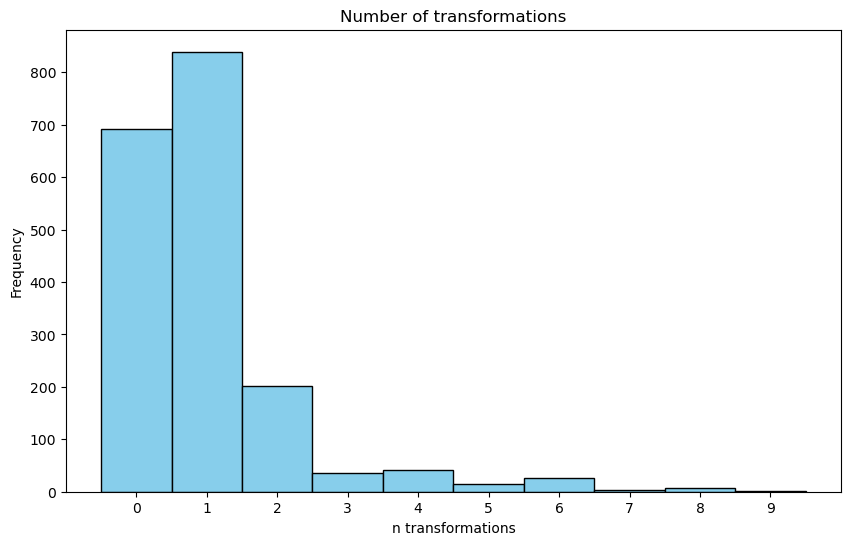

In [6]:
filtered_df = df[df['n_transformations'] < 10]
plt.figure(figsize=(10, 6))
plt.hist(filtered_df['n_transformations'], bins= int(filtered_df['n_transformations'].max()) + 1, range=(0-0.5, filtered_df['n_transformations'].max()+0.5), color='skyblue', edgecolor='black')
plt.xticks(filtered_df['n_transformations'].unique())

# Adding labels and title

plt.xlabel('n transformations')
plt.ylabel('Frequency')
plt.title('Number of transformations')

#### Pairs with 2 clusters for specific ligand residues

In [12]:
def has_2_trans(values):
    for val in values:
        if len(val) == 2:
            return True
    return False

has_two_clusters = df['coverage'].apply(has_2_trans)
print(has_two_clusters.sum())
df[has_two_clusters].head()

42


,Ligand_ID,ref_protein,mov_protein,ref_chain,mov_chain,n_transformations,rotations,translations,rmse,coverage,cath_degree,ref_ligand_n_atoms,mov_ligand_n_atoms,failure message,gap,total_gap
3,SAH,3g2p,4cng,A,A,3.0,"([array([[ 0.57599604, 0.80216295, -0.1573635...","([[...], [...]], [[...], [...]])","[[0.13120175322499833], [0.216526329259685, 0....","[[0.46153846153846156], [0.46153846153846156, ...",2,26.0,52.0,NaN,"[1.3303367083134634, 1.2450121322787764, 1.345...",3.920597
61,ADP,1htw,6rm8,A,A,2.0,"([array([[-0.36912122, 0.0051997 , 0.9293667...","([[...]],)","[[0.11807229191998794, 0.2817916377696649]]","[[0.4074074074074074, 0.4074074074074074]]",0,27.0,27.0,NaN,"[1.2893351154874195, 1.1256157696377425]",2.414951
163,ATP,4bjr,7ua3,A,A,3.0,"([array([[-0.85318696, -0.47521004, -0.2150521...","([[...], [...]], [[...], [...]])","[[0.2822979706181066, 0.05390241499347764], [0...","[[0.45161290322580644, 0.3548387096774194], [0...",0,31.0,62.0,NaN,"[1.1693149326077, 1.3009362946839418, 1.397101...",3.867353
414,NAD,3haz,3jzd,A,A,2.0,"([array([[ 0.193617 , -0.15625215, -0.9685544...","([[...]],)","[[0.30057930103389696, 0.2344208297338497]]","[[0.3409090909090909, 0.3409090909090909]]",0,44.0,44.0,NaN,"[1.040329789875194, 1.1064882611752411]",2.146818
421,NAD,2pzm,4h03,A,A,2.0,"([array([[-0.8903783 , 0.43307868, 0.1402471...","([[...]],)","[[0.2801089634333056, 0.15644479116345517]]","[[0.3409090909090909, 0.3181818181818182]]",1,44.0,44.0,NaN,"[1.0608001274757852, 1.161737027018363]",2.222537


### Failres

/tmp/ipykernel_203200/2420978838.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['failure message'].dropna(), data=df, palette='viridis')


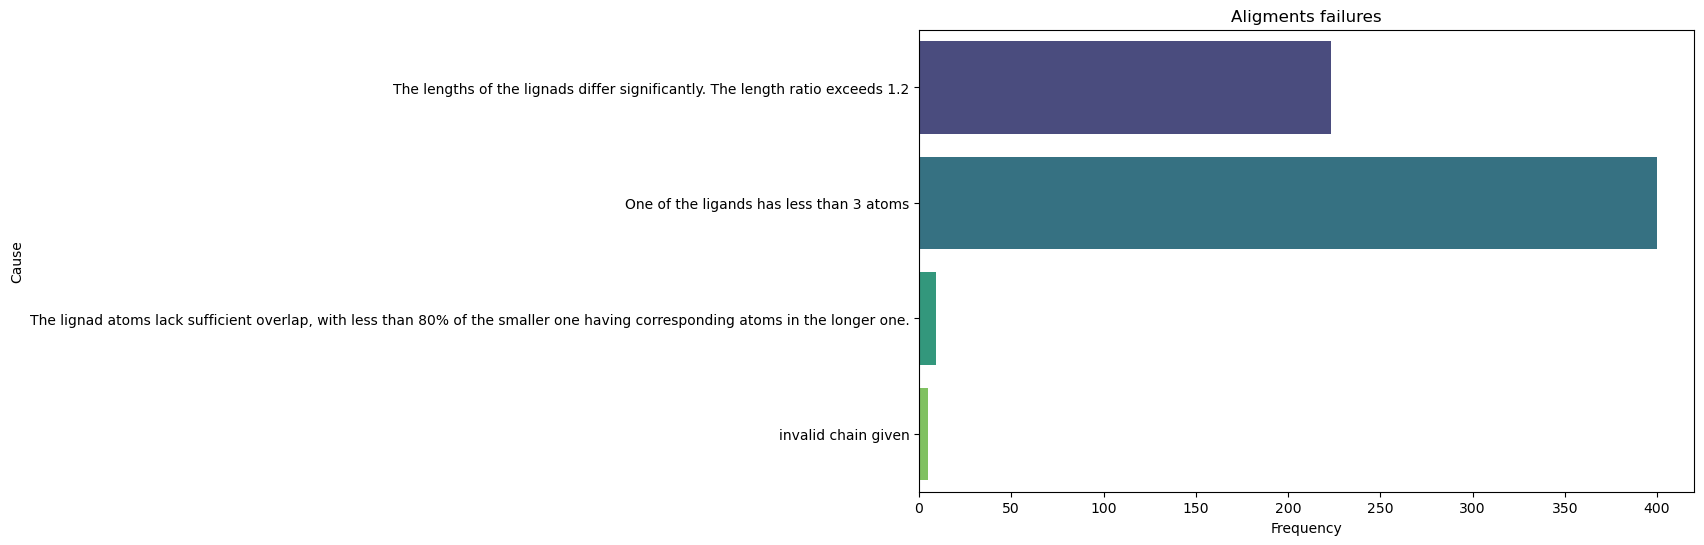

In [8]:
plt.figure(figsize=(10, 6)) 
sns.countplot(y=df['failure message'].dropna(), data=df, palette='viridis')
plt.xlabel('Frequency')
plt.ylabel('Cause')
plt.title('Aligments failures')
plt.show()

#### Ligands have different number of atoms

In [9]:
df[df['failure message'] == "The lengths of the lignads differ significantly. The length ratio exceeds 1.2"].head()

,Ligand_ID,ref_protein,mov_protein,ref_chain,mov_chain,n_transformations,rotations,translations,rmse,coverage,cath_degree,ref_ligand_n_atoms,mov_ligand_n_atoms,failure message
2,SAH,3lby,7ux7,A,A,0.0,(),(),[],[],0,26.0,45.0,The lengths of the lignads differ significantl...
5,SAH,6gkv,7kff,A,A,0.0,(),(),[],[],0,26.0,45.0,The lengths of the lignads differ significantl...
46,ADP,4ebu,5fm6,A,A,0.0,(),(),[],[],0,27.0,42.0,The lengths of the lignads differ significantl...
53,ADP,3mbi,8as8,A,A,0.0,(),(),[],[],0,27.0,39.0,The lengths of the lignads differ significantl...
69,HEM,7m8i,7oqr,A,A,0.0,(),(),[],[],0,73.0,43.0,The lengths of the lignads differ significantl...


In [10]:
df[df['failure message'] == "One of the ligands has less than 3 atoms"].head()

,Ligand_ID,ref_protein,mov_protein,ref_chain,mov_chain,n_transformations,rotations,translations,rmse,coverage,cath_degree,ref_ligand_n_atoms,mov_ligand_n_atoms,failure message
64,HEM,1drm,1jju,A,B,0.0,(),(),[],[],0,43.0,0.0,One of the ligands has less than 3 atoms
84,NaN,3r0x,4zla,A,A,0.0,(),(),[],[],2,0.0,0.0,One of the ligands has less than 3 atoms
85,NaN,1c9o,8hir,A,A,0.0,(),(),[],[],0,0.0,0.0,One of the ligands has less than 3 atoms
86,NaN,3pak,4zla,A,A,0.0,(),(),[],[],1,0.0,0.0,One of the ligands has less than 3 atoms
87,NaN,5nv9,8cv2,A,A,0.0,(),(),[],[],0,0.0,0.0,One of the ligands has less than 3 atoms


## CATH analsys:


Text(0.5, 1.0, 'mean of (1-mse) + coverage')

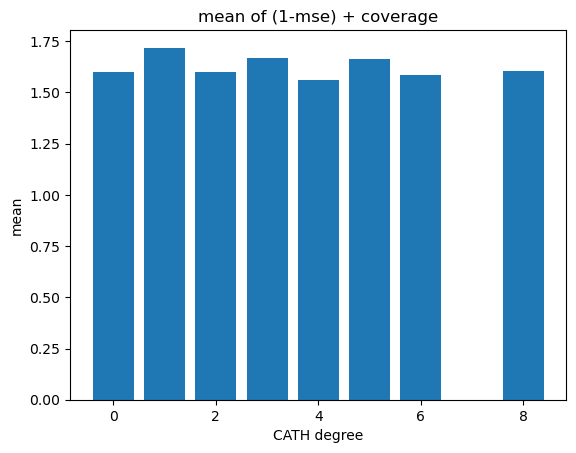

In [11]:

def sum_per_row(lst):
    return sum(lst)  if lst else None

def calculate_gap(row):
    ret = []
    for coverage, rmse in zip(row['coverage'], row['rmse']):
        for i in range(len(coverage)):
            ret.append(coverage[i] + (1- rmse[i]))
    return ret

df['gap'] = df.apply(calculate_gap, axis=1)
df['total_gap'] = df['gap'].apply(sum_per_row)
mean_values = df.groupby('cath_degree')['total_gap'].sum() / df.groupby('cath_degree')['n_transformations'].sum()

# Step 2: Create the histogram
plt.bar(mean_values.index, mean_values.values)
plt.xlabel('CATH degree')
plt.ylabel('mean')
plt.title('mean of (1-mse) + coverage')